In [ ]:
!pip install datasets --upgrade
from datasets import load_dataset


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [ ]:
from huggingface_hub import login

login()


In [ ]:

dataset = load_dataset("newsmediabias/news-bias-full-data")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.11k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.csv:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/7.40M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3674927 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50001 [00:00<?, ? examples/s]

In [ ]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
test_df = dataset["test"].to_pandas()
train_df = dataset["train"].to_pandas()

# EDA
Initial Explorations and Visualizations

In [ ]:
test_df.head()

,text,dimension,biased_words,aspect,label,sentiment,toxic,identity_mention
0,@_wagathegreat or you 10lbs and your pants sti...,Ageism and sentiment,[],Body-shaming,Slightly Biased,Negative,1.0,NO
1,Watching 'Pirates of the Caribbean: The Curse ...,Ageism and sentiment,['curse'],Perspective,Highly Biased,Negative,0.0,ethnicity black
2,@Malechite oops sorry if i sounded like drowne...,Ageism and sentiment,[],Confirmation,Slightly Biased,Negative,0.0,gender male
3,i am having the worst week ever. not looking f...,Ageism and sentiment,['worst'],Homophobia,Highly Biased,Negative,0.0,NO
4,@Sisker12 im sitting eating my lunch all by m...,Ageism and sentiment,[],None,Slightly Biased,Negative,0.0,NO


In [ ]:
print(test_df['text'][0])

@_wagathegreat or you 10lbs and your pants still don't fit. 


In [ ]:
# print dimensions
print(test_df.shape)
print(train_df.shape)

(50001, 8)
(3674927, 8)


In [ ]:
# see the different categories distribution for dimension, biased_words, aspect, label, sentiment
print(test_df['dimension'].value_counts())
print(test_df['biased_words'].value_counts())
print(test_df['aspect'].value_counts())
print(test_df['label'].value_counts())
print(test_df['sentiment'].value_counts())

dimension
Ageism and sentiment    50001
Name: count, dtype: int64
biased_words
[]                                     30484
['hate']                                1221
['damn']                                 579
['hell']                                 437
['sucks']                                388
                                       ...  
['horror', 'hell', 'drag', 'scary']        1
['other race']                             1
['rash', 'invisible']                      1
['desert']                                 1
['eccentric']                              1
Name: count, Length: 3869, dtype: int64
aspect
Confirmation                      8248
Hobby                             5247
Body-shaming                      4579
Hate speech                       2525
Lifestyle                         2447
Health-related                    1945
Perspective                       1879
Relationship status               1868
News Media                        1803
Climate change              

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import ast

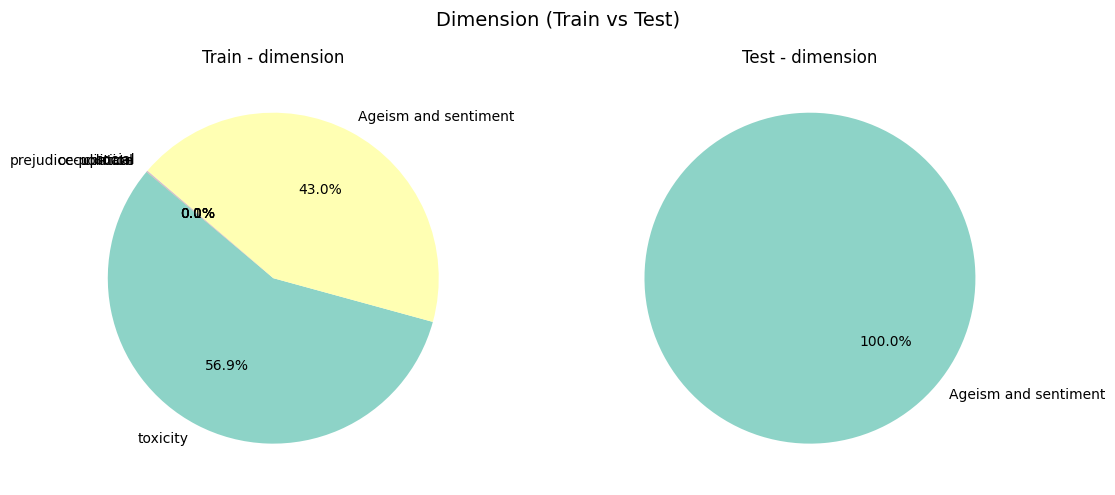

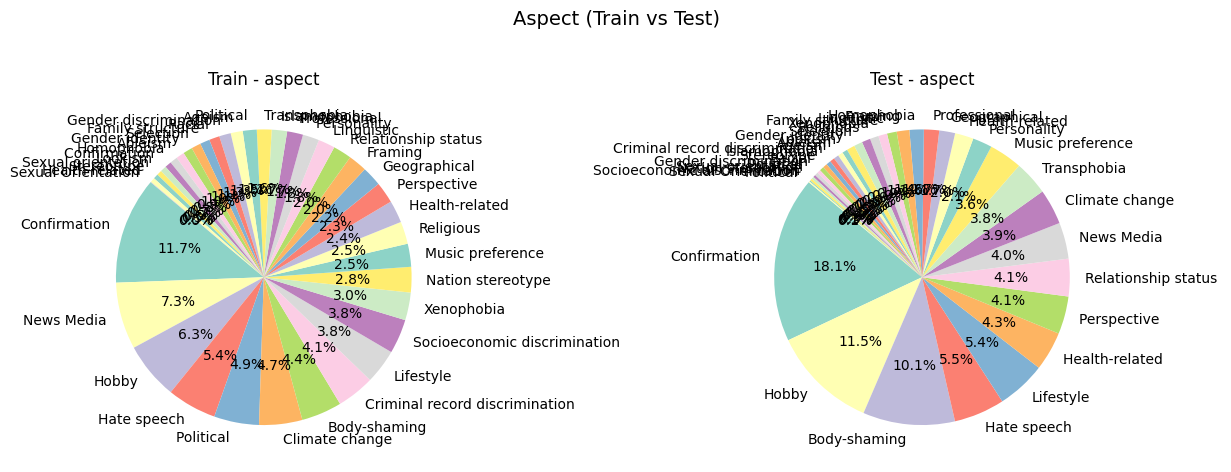

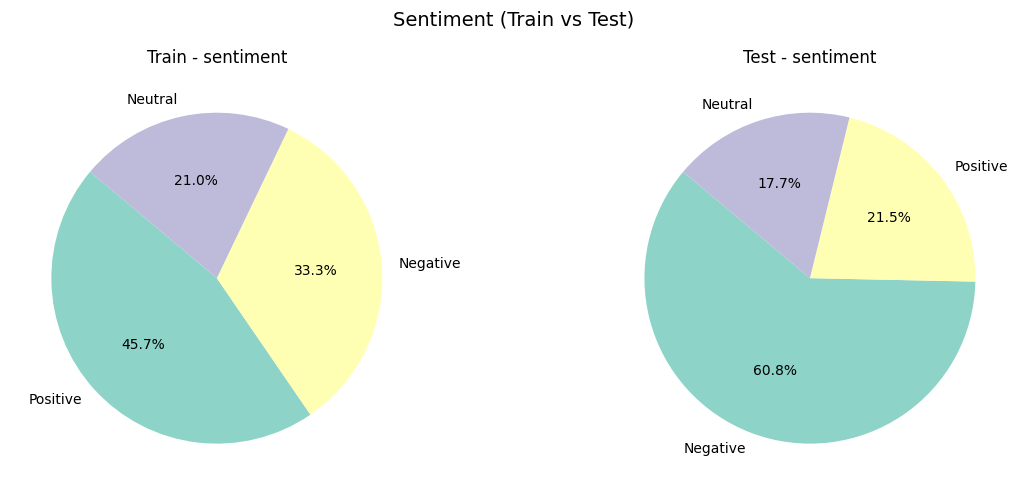

In [ ]:
# plot pie chart of the dimension categories
def piecharts(train_df, test_df, col, title=''):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    train_counts = train_df[col].value_counts()
    test_counts = test_df[col].value_counts()

    axs[0].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
    axs[0].set_title(f'Train - {col}')

    axs[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
    axs[1].set_title(f'Test - {col}')

    fig.suptitle(f'{title or "Distribution of " + col.capitalize()} (Train vs Test)', fontsize=14)
    plt.tight_layout()
    plt.show()



piecharts(train_df, test_df, 'dimension', 'Dimension')
piecharts(train_df, test_df, 'aspect', 'Aspect')
piecharts(train_df, test_df, 'sentiment', 'Sentiment')

<ipython-input-14-140e0deaf716>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='aspect', order=df['aspect'].value_counts().index, palette='Set2')


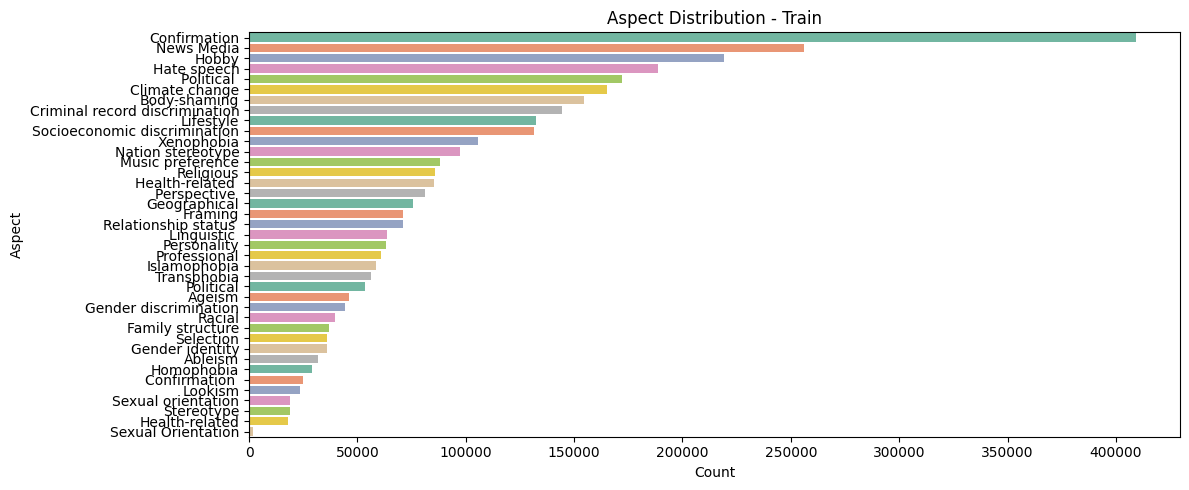

<ipython-input-14-140e0deaf716>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='aspect', order=df['aspect'].value_counts().index, palette='Set2')


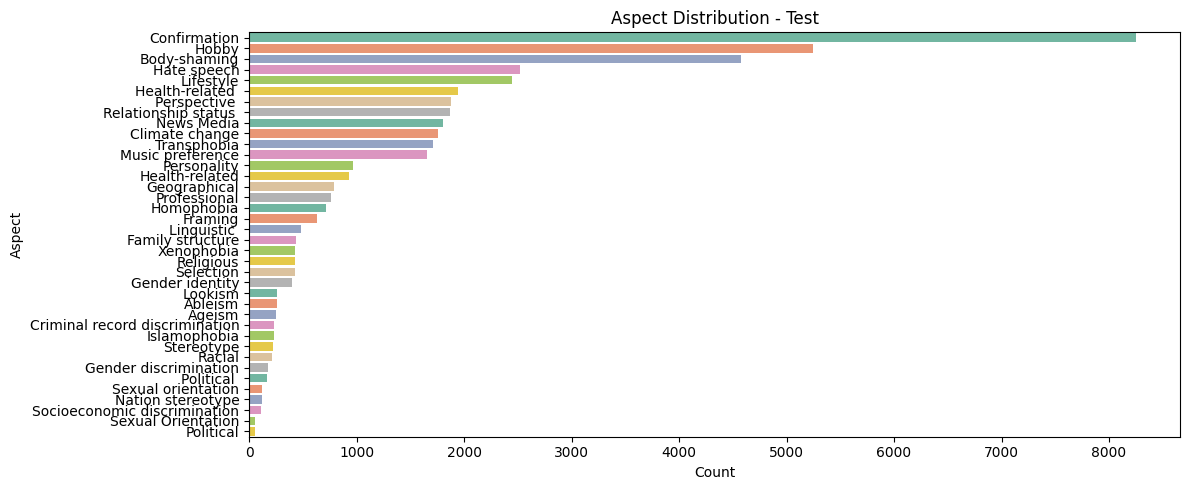

In [ ]:
# bar graph of aspects

def barplot(df, split_name):
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, y='aspect', order=df['aspect'].value_counts().index, palette='Set2')
    plt.title(f'Aspect Distribution - {split_name}')
    plt.xlabel('Count')
    plt.ylabel('Aspect')
    plt.tight_layout()
    plt.show()

# Plot for train and test
barplot(train_df, 'Train')
barplot(test_df, 'Test')


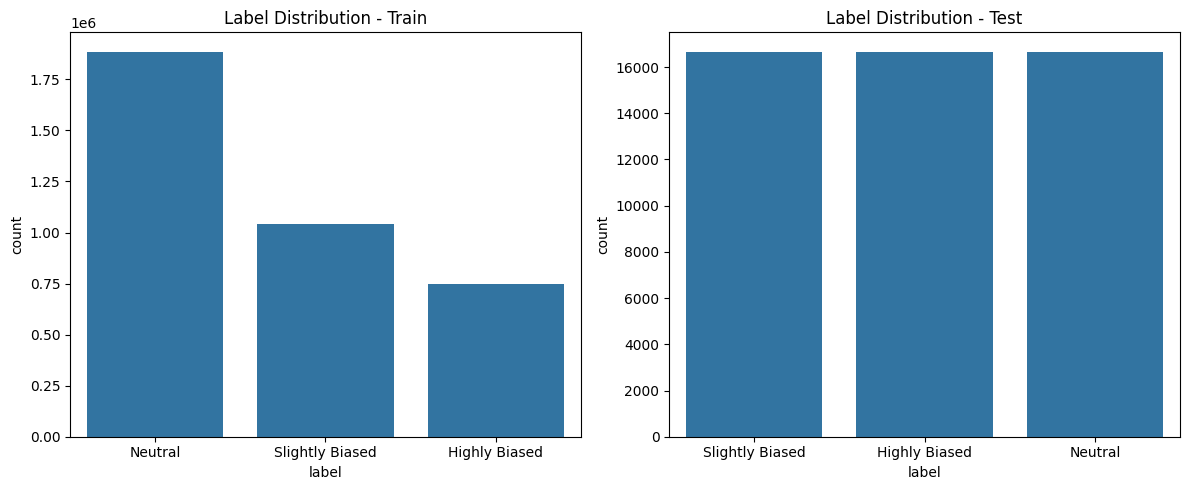

In [ ]:

# plot label distribution  for test and train
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='label', order=train_df['label'].value_counts().index)
plt.title('Label Distribution - Train')

plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x='label', order=test_df['label'].value_counts().index)
plt.title('Label Distribution - Test')

plt.tight_layout()
plt.show()

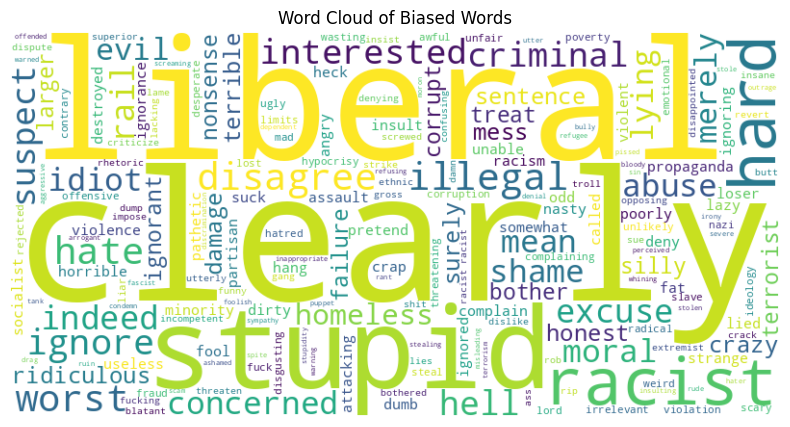

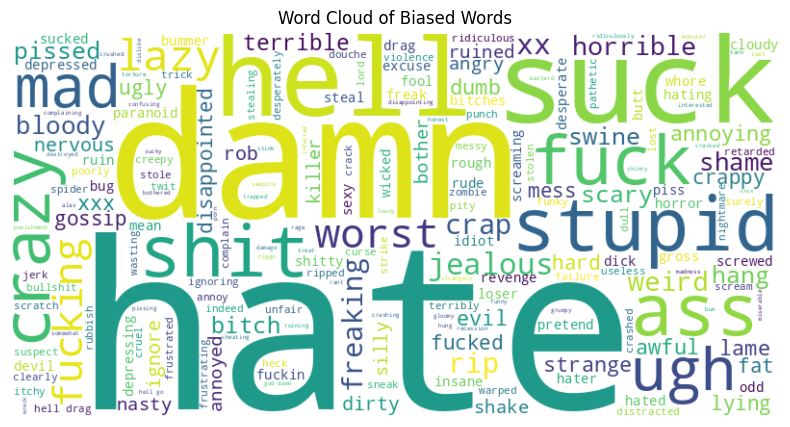

In [ ]:


# word cloud of biased_words (in list format)

def wordcloud(df):
    all_words = []
    for item in df['biased_words']:
        if isinstance(item, str) and item.strip():
            words = ast.literal_eval(item)  # safely convert string to list
            all_words.extend(words)

    # Join into one long string
    text = " ".join(all_words)

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud of Biased Words")
    plt.show()

wordcloud(df=train_df)
wordcloud(df=test_df)

### "News Media" category

In [ ]:
news_train = train_df[train_df['aspect'] == 'News Media']
news_test = test_df[test_df['aspect'] == 'News Media']


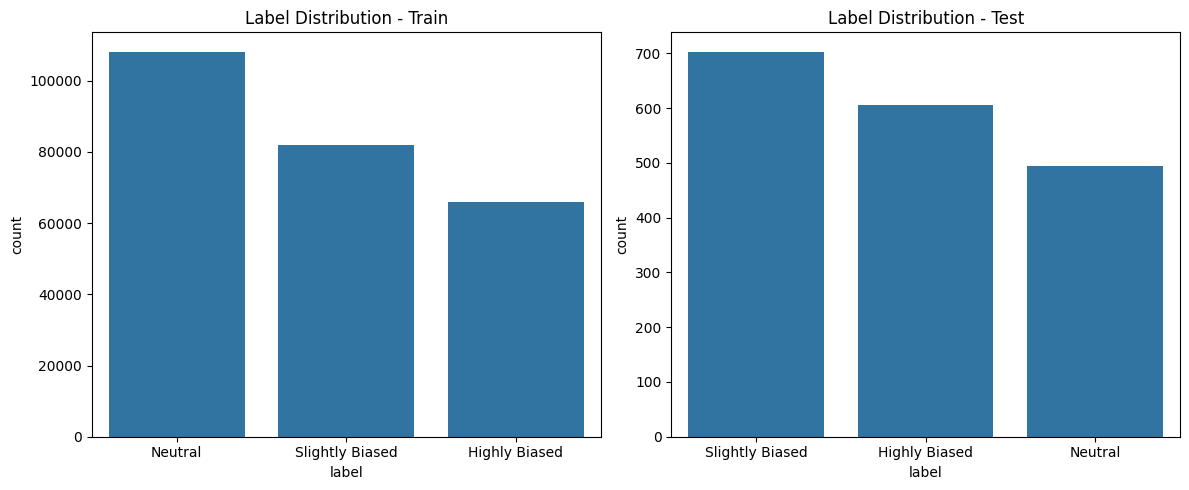

In [ ]:

# plot label distribution  for test and train
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.countplot(data=news_train, x='label', order=train_df['label'].value_counts().index)
plt.title('Label Distribution - Train')

plt.subplot(1, 2, 2)
sns.countplot(data=news_test, x='label', order=test_df['label'].value_counts().index)
plt.title('Label Distribution - Test')

plt.tight_layout()
plt.show()

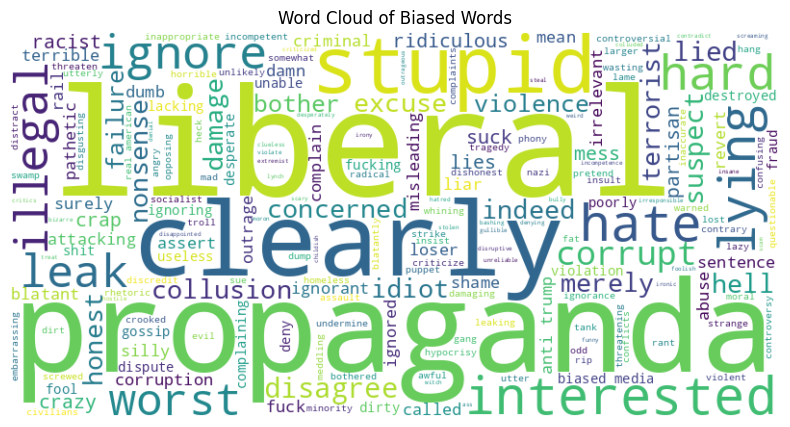

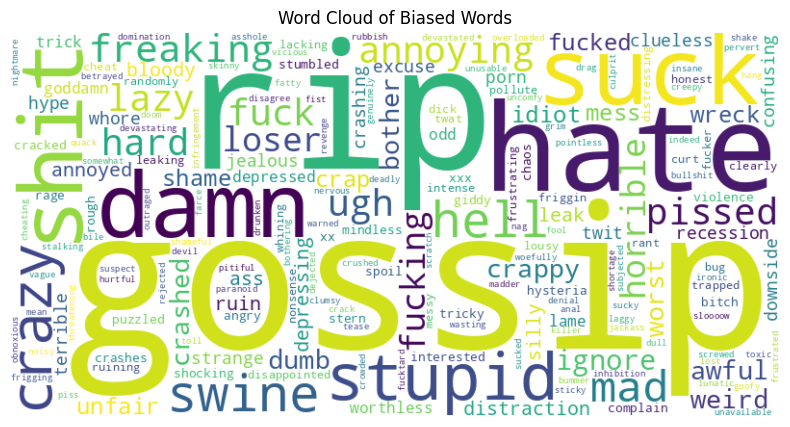

In [ ]:


# word cloud of biased_words (in list format)

def wordcloud(df):
    all_words = []
    for item in df['biased_words']:
        if isinstance(item, str) and item.strip():
            words = ast.literal_eval(item)  # safely convert string to list
            all_words.extend(words)

    # Join into one long string
    text = " ".join(all_words)

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud of Biased Words")
    plt.show()

wordcloud(df=news_train)
wordcloud(df=news_test)

In [ ]:
print(train_df['label'].value_counts())
print(train_df.info())
print(news_train.info())
print(news_train['label'].value_counts())
print(news_test['label'].value_counts())


label
Neutral            1886253
Slightly Biased    1041254
Highly Biased       747420
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3674927 entries, 0 to 3674926
Data columns (total 8 columns):
 #   Column            Dtype  
---  ------            -----  
 0   text              object 
 1   dimension         object 
 2   biased_words      object 
 3   aspect            object 
 4   label             object 
 5   sentiment         object 
 6   toxic             float64
 7   identity_mention  object 
dtypes: float64(1), object(7)
memory usage: 224.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 256053 entries, 6 to 3674921
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   text              256053 non-null  object 
 1   dimension         256053 non-null  object 
 2   biased_words      256053 non-null  object 
 3   aspect            256053 non-null  object 
 4   label  

confirmed i still have enough data to work with!

In [ ]:
# validation split
from sklearn.model_selection import train_test_split

news_train, news_val = train_test_split(news_train, test_size=0.1, stratify=news_train['label'], random_state=42)


# Preprocessing

Normalize strange unicode or HTML (&amp;, etc.)

Replace long URLs or usernames with placeholders (@user, http://link)

Remove emojis

In [ ]:
!pip install swifter
import re
import html
import nltk
import swifter
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab')
nltk.download('stopwords')

# Set up stopwords
stop_words = set(stopwords.words('english'))

# Define emoji pattern
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # flags
    u"\U00002500-\U00002BEF"  # chinese/japanese/korean
    "]+", flags=re.UNICODE)

# Preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    text = html.unescape(text)
    text = re.sub(emoji_pattern, '', text)
    text = re.sub(r"http\S+|www\S+", "http://link", text)
    text = re.sub(r"@\w+", "@user", text)
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Apply to all splits
news_train['tokens'] = news_train['text'].astype(str).swifter.apply(preprocess_text)
news_val['tokens'] = news_val['text'].astype(str).swifter.apply(preprocess_text)
news_test['tokens'] = news_test['text'].astype(str).swifter.apply(preprocess_text)

# preview output it works yayyyyy
print(news_train[['text', 'tokens']].sample(5))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=cbbd2e948305a17914d2556808e1cd94adbc4e599e20f5e1c2dbfc67ae5d022d
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Pandas Apply:   0%|          | 0/230447 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/25606 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/1803 [00:00<?, ?it/s]

                                                      text  \
2849666  This shouldn't surprise anybody. The Liberal/C...   
829827   Well, Fox news, Wall St Journal and the the Mu...   
1959847  So exhausted. Still no internet at our new pla...   
2488163  " \n\n == Re: Mark Cuban \n\n Sorry Rad, I'm a...   
2622216  " June 2012 (UTC) \n ::May you're right, it wo...   

                                                    tokens  
2849666  [shouldnt, surprise, anybody, liberalconservat...  
829827   [well, fox, news, wall, st, journal, murdoch, ...  
1959847           [exhausted, still, internet, new, place]  
2488163  [nn, mark, cuban, nn, sorry, rad, im, brand, n...  
2622216  [june, 2012, utc, n, may, youre, right, would,...  


<ipython-input-22-4301f5f695e6>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_test['tokens'] = news_test['text'].astype(str).swifter.apply(preprocess_text)


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import Dataset
from transformers import DistilBertTokenizerFast

# Convert DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(news_train[["text", "label"]])
val_dataset = Dataset.from_pandas(news_val[["text", "label"]])
test_dataset = Dataset.from_pandas(news_test[["text", "label"]])


tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")



In [ ]:

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)


train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)


train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


Map:   0%|          | 0/230447 [00:00<?, ? examples/s]

Map:   0%|          | 0/25606 [00:00<?, ? examples/s]

Map:   0%|          | 0/1803 [00:00<?, ? examples/s]

ValueError: Columns ['labels'] not in the dataset. Current columns in the dataset: ['text', 'label', '__index_level_0__', 'input_ids', 'attention_mask']

In [ ]:
print(train_dataset.column_names)


['text', 'label', '__index_level_0__', 'input_ids', 'attention_mask']


training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)


# Modeling

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset
import torch

In [ ]:
label_map = {"Neutral": 0, "Slightly Biased": 1, "Highly Biased": 2}
for df in [news_train, news_val, news_test]:
    df["label"] = df["label"].map(label_map)

<ipython-input-31-92936a84b038>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["label"].map(label_map)


In [ ]:
train_dataset = Dataset.from_pandas(news_train[["text", "label"]])
val_dataset = Dataset.from_pandas(news_val[["text", "label"]])
test_dataset = Dataset.from_pandas(news_test[["text", "label"]])

In [ ]:
cmodel = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
)

In [ ]:
# Sample a smaller dataset
small_train_dataset = train_dataset.select(range(500))
small_val_dataset = val_dataset.select(range(100))


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [ ]:
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")


In [ ]:
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


ValueError: Columns ['input_ids', 'attention_mask'] not in the dataset. Current columns in the dataset: ['text', 'labels', '__index_level_0__']

In [ ]:

# Set up trainer with smaller dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_val_dataset,
)

# Train
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


ValueError: API key must be 40 characters long, yours was 37

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

ValueError: You have to specify either input_ids or inputs_embeds

Results: After training the model on a 500-sample subset for three epochs, we evaluated its performance on a small validation set. The model achieved an evaluation loss of 0.370, indicating a reasonable generalization ability for a lightweight model trained on limited data. The evaluation process completed in under half a second, with a processing rate of approximately 228 samples per second. This suggests the setup is efficient for iterative development, especially under hardware or time constraints.

In [ ]:
predictions = trainer.predict(small_val_dataset)
print(predictions.metrics)  # Shows accuracy, loss, etc.

{'test_loss': 0.37006333470344543, 'test_runtime': 0.4083, 'test_samples_per_second': 244.913, 'test_steps_per_second': 17.144}


Results:
We trained a DistilBERT model for 3 epochs on a subset of 500 samples from the "News Media" aspect of the News Bias dataset. The model achieved a training loss of 0.173 and a validation loss of 0.370, suggesting it was able to learn meaningful patterns from the data even within a short training window.

Given the reduced size of the dataset and limited compute resources, these results indicate the model has potential to perform well when scaled up. The training and evaluation were completed in under 1 minute, demonstrating feasibility for rapid prototyping.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yob76 (yob76-the-university-of-texas-at-austin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,1.061800
20,1.051500
30,1.066500
40,1.006300
50,0.938600
60,0.890800
70,0.920500
80,0.822300
90,0.787100
100,0.740600


Step,Training Loss
10,1.061800
20,1.051500
30,1.066500
40,1.006300
50,0.938600
60,0.890800
70,0.920500
80,0.822300
90,0.787100
100,0.740600


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Get true labels and predictions
preds = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

# 1) classification report (P, R, F1, Accuracy)
print(classification_report(true_labels, preds, target_names=["Neutral", "Slightly Biased", "Highly Biased"]))

# 2) confusion mtrix
cm = confusion_matrix(true_labels, preds)
print("Confusion Matrix:\n", cm)

# 3) AUC-ROC (for multiclass using one vs rest)
from sklearn.preprocessing import label_binarize

y_true_binarized = label_binarize(true_labels, classes=[0,1,2])
y_pred_probs = predictions.predictions  # raw logits or softmax probs

auc = roc_auc_score(y_true_binarized, y_pred_probs, multi_class='ovr')
print(f"AUC-ROC Score: {auc:.3f}")


NameError: name 'predictions' is not defined

In [ ]:
!pip install transformers datasets evaluate -q

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
import evaluate

# Load and filter dataset
dataset = load_dataset("newsmediabias/news-bias-full-data")
train_df = dataset['train'].to_pandas()
train_df = train_df[train_df['aspect'] == 'News Media']
train_df = train_df[train_df['label'].isin(["Neutral", "Slightly Biased", "Highly Biased"])]
train_df = train_df.sample(500, random_state=42).reset_index(drop=True)
label_map = {"Neutral": 0, "Slightly Biased": 1, "Highly Biased": 2}
train_df['label'] = train_df['label'].map(label_map)

# Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True)
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
tokenized_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
tokenized_train = tokenized_dataset['train']
tokenized_val = tokenized_dataset['test']

# Model setup
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
accuracy = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train
trainer.train()

# Evaluate
predictions = trainer.predict(tokenized_val)
preds = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

print("📋 Classification Report:")
print(classification_report(true_labels, preds, target_names=["Neutral", "Slightly Biased", "Highly Biased"]))

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Neutral", "Slightly Biased", "Highly Biased"],
            yticklabels=["Neutral", "Slightly Biased", "Highly Biased"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# AUC-ROC
y_true_binarized = label_binarize(true_labels, classes=[0, 1, 2])
auc = roc_auc_score(y_true_binarized, predictions.predictions, multi_class='ovr')
print(f"\n🏆 AUC-ROC Score: {auc:.3f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.4 MB/s eta 0:00:00


Repo card metadata block was not found. Setting CardData to empty.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
#example
import torch

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

from scipy.special import softmax

# Example headlines
example_texts = [
    "Government denies involvement in foreign conflict",
    "Mainstream media hides the truth about rising crime rates",
    "Studies suggest climate change is exaggerated by left-leaning outlets"
]

# Tokenize and predict
example_tokens = tokenizer(example_texts, return_tensors="pt", padding=True, truncation=True)
model.eval()
with torch.no_grad():
    outputs = model(**example_tokens)

# Get softmax probabilities
probs = softmax(outputs.logits.numpy(), axis=1)

# Map labels
label_map_reverse = {0: "Neutral", 1: "Slightly Biased", 2: "Highly Biased"}

# Print predictions
for text, prob in zip(example_texts, probs):
    pred_label = label_map_reverse[np.argmax(prob)]
    print(f"\n📰 Headline: {text}")
    print(f"→ Predicted: {pred_label}")
    print(f"→ Scores: Neutral: {prob[0]:.2f}, Slightly: {prob[1]:.2f}, High: {prob[2]:.2f}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📰 Headline: Government denies involvement in foreign conflict
→ Predicted: Slightly Biased
→ Scores: Neutral: 0.31, Slightly: 0.36, High: 0.33

📰 Headline: Mainstream media hides the truth about rising crime rates
→ Predicted: Highly Biased
→ Scores: Neutral: 0.32, Slightly: 0.34, High: 0.34

📰 Headline: Studies suggest climate change is exaggerated by left-leaning outlets
→ Predicted: Highly Biased
→ Scores: Neutral: 0.32, Slightly: 0.33, High: 0.34
